<a href="https://colab.research.google.com/github/kthanikonda/Privacy-Aware-Computing/blob/main/Privacy_Doc-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! pip install textstat swifter

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.3/105.3 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.4/939.4 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 21.4 MB/s eta 0:00:00
  Created wheel for swifter: filename=swifter-1.4.0-py3-none-any.whl size=16507 sha256=5426e8a0122d1949456efa41ec560c074be758711790e9e5ef87cbfb72535f69
  Stored in directory: /root/.cache/pip/wheels/ef/7f/bd/9bed48f078f3ee1fa75e0b29b6e0335ce1cb03a38d3443b3a3
Successfully built swifter


In [2]:
import nltk
import spacy
import numpy as np
import textstat
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords, wordnet as wn
from nltk import pos_tag
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from wordcloud import WordCloud
from textblob import TextBlob
from google.colab import files
import hashlib
from numpy.random import laplace
import swifter
import multiprocessing

#  STEP 1: File Upload & Reading
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f" Uploaded file: {filename}")
df_squad = pd.read_excel(filename, engine='openpyxl')
df_squad.head()


Saving Squad.xlsx to Squad.xlsx
 Uploaded file: Squad.xlsx


,question
0,To whom did the Virgin Mary allegedly appear i...
1,What is in front of the Notre Dame Main Building?
2,The Basilica of the Sacred heart at Notre Dame...
3,What is the Grotto at Notre Dame?
4,What sits on top of the Main Building at Notre...


In [3]:
#  STEP 2: Download NLTK Resources
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

# Load NLP & Stopwords
nlp = spacy.load("en_core_web_sm")
stop_words = set(stopwords.words("english"))


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


In [24]:
import spacy
import random
import pandas as pd

# Load the pre-trained spaCy model
nlp = spacy.load("en_core_web_sm")

# Named Entity Redaction with Meaning Preservation
def replace_named_entities(text):
    # Define replacements for various named entity types
    entity_replacements = {
        "PERSON": ["A Historical Figure", "A Renowned Individual"],
        "ORG": ["An Established Organization", "A Well-Known Institution"],
        "GPE": ["A Notable Region", "A Recognized Location"],
        "DATE": ["A Certain Year", "Some Time Ago"],
        "TIME": ["Earlier Today", "A Short While Ago"],
        "FAC": ["A Recognized Building", "A Known Monument"],
        "LOC": ["A Specific Location", "A Known Area"]
    }

    # Process the input text using spaCy
    doc = nlp(text)

    # Create a list to store the transformed parts of the text
    new_text_parts = []

    # Track the last end position for inserting non-entity text
    last_end = 0

    for ent in doc.ents:
        # Append the part of the text before the entity
        new_text_parts.append(text[last_end:ent.start_char])

        # If a valid replacement is found, replace the entity with a random choice
        if ent.label_ in entity_replacements:
            replacement = random.choice(entity_replacements[ent.label_])
            new_text_parts.append(replacement)

        # Update the position to the end of the current entity
        last_end = ent.end_char

    # Append any remaining part of the text after the last entity
    new_text_parts.append(text[last_end:])

    # Join the parts to form the new sanitized sentence
    return ''.join(new_text_parts)


#  Apply Named Entity Redaction to your dataset
df_squad["sanitized_question"] = df_squad["question"].apply(replace_named_entities)

#  Display First 5 Rows of the sanitized dataset
print("\nNamed Entity Redaction Completed\n")
for i in range(min(5, len(df_squad))):
    original = df_squad.loc[i, "question"]
    sanitized = df_squad.loc[i, "sanitized_question"]

    print(f"Original Question: {original}")
    print(f"Sanitized Question: {sanitized}")
    print("-" * 80)

# Save the sanitized dataset
sanitized_file_path = "sanitized_squad_fixed.csv"
df_squad.to_csv(sanitized_file_path, index=False)
print(f"Named Entity Redacted Data saved as: {sanitized_file_path}")



Named Entity Redaction Completed

Original Question: To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
Sanitized Question: To whom did A Known Monument allegedly appear in Some Time Ago in A Renowned Individual?
--------------------------------------------------------------------------------
Original Question: What is in front of the Notre Dame Main Building?
Sanitized Question: What is in front of A Recognized Building?
--------------------------------------------------------------------------------
Original Question: The Basilica of the Sacred heart at Notre Dame is beside to which structure?
Sanitized Question: The Basilica of the A Renowned Individual heart at A Recognized Building is beside to which structure?
--------------------------------------------------------------------------------
Original Question: What is the Grotto at Notre Dame?
Sanitized Question: What is the Grotto at A Recognized Building?
-----------------------------------------------------

In [25]:
import spacy
import os
os.system("python -m spacy download en_core_web_md")  # Install in runtime
nlp = spacy.load("en_core_web_md")  # Load after installation


In [37]:
# Mapping POS tags to WordNet POS
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'): return wn.ADJ
    elif treebank_tag.startswith('V'): return wn.VERB
    elif treebank_tag.startswith('N'): return wn.NOUN
    elif treebank_tag.startswith('R'): return wn.ADV
    else: return None

# DP Text Perturbation Function with Exponential Mechanism
def dp_text_perturbation(text, prob=0.3, epsilon=1.0):
    words = word_tokenize(text)
    pos_tags = pos_tag(words)
    perturbed_text = []

    for word, tag in pos_tags:
        if random.random() < prob:  # Apply perturbation based on probability
            wn_pos = get_wordnet_pos(tag)  # Get the corresponding WordNet POS tag
            synonyms = wn.synsets(word, pos=wn_pos) if wn_pos else wn.synsets(word)
            synonym_list = [lemma.name() for syn in synonyms for lemma in syn.lemmas() if "_" not in lemma.name()]
            synonym_list = list(set(synonym_list))  # Remove duplicates

            if synonym_list:
                # Apply Laplace noise to score the synonyms for differential privacy
                scores = np.random.laplace(0, 1 / epsilon, len(synonym_list))  # Laplace noise
                probabilities = np.exp(epsilon * scores) / np.sum(np.exp(epsilon * scores))  # Normalize probabilities
                perturbed_word = np.random.choice(synonym_list, p=probabilities)  # Select synonym based on probabilities
                perturbed_text.append(perturbed_word)
                continue

        perturbed_text.append(word)  # No perturbation for this word

    return ' '.join(perturbed_text)

# Apply DP Perturbation to Sanitized Questions
df_squad["dp_perturbation"] = df_squad["sanitized_question"].apply(lambda x: dp_text_perturbation(x, epsilon=1.0))

# Display First 5 Rows
print("\n DP Perturbation with Exponential Mechanism Applied\n")
for i in range(min(5, len(df_squad))):
    original = df_squad.loc[i, "question"]
    sanitized = df_squad.loc[i, "sanitized_question"]
    perturbed = df_squad.loc[i, "dp_perturbation"]

    print(f"Original Question: {original}")
    print(f"Sanitized Question: {sanitized}")
    print(f"DP Perturbed Question: {perturbed}")
    print("-" * 80)

# Save Processed Data
dp_perturb_file_path = "dp_squad_final_fixed.csv"
df_squad.to_csv(dp_perturb_file_path, index=False)
print(f" DP Perturbation with Exponential Mechanism Data saved as: {dp_perturb_file_path}")


 DP Perturbation with Exponential Mechanism Applied

Original Question: To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
Sanitized Question: To whom did A Known Monument allegedly appear in Some Time Ago in A Renowned Individual?
DP Perturbed Question: To whom perform A Known Monument allegedly appear in approximately Time Ago in A Renowned somebody ?
--------------------------------------------------------------------------------
Original Question: What is in front of the Notre Dame Main Building?
Sanitized Question: What is in front of A Recognized Building?
DP Perturbed Question: What is in front of A Recognized Building ?
--------------------------------------------------------------------------------
Original Question: The Basilica of the Sacred heart at Notre Dame is beside to which structure?
Sanitized Question: The Basilica of the A Renowned Individual heart at A Recognized Building is beside to which structure?
DP Perturbed Question: The Basilica of the

In [38]:
# Train Word2Vec Model on DP-Perturbed Text
sentences = [text.split() for text in df_squad['dp_perturbation']]
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=multiprocessing.cpu_count())

# Compute Mean Embedding for OOV Words
mean_embedding = np.mean(w2v_model.wv.vectors, axis=0)

# Function to Get Sentence Embedding with Minimal Laplace Noise
def get_sentence_embedding(text, epsilon=1.5):
    words = text.split()
    word_vectors = [w2v_model.wv[word] if word in w2v_model.wv else mean_embedding for word in words]
    embedding = np.mean(word_vectors, axis=0) if word_vectors else mean_embedding
    noise = laplace(0, 1 / epsilon, embedding.shape)  # **Reduce noise for consistency**
    return embedding + noise

# Apply Embeddings
df_squad['original_embedding'] = df_squad['sanitized_question'].swifter.apply(lambda x: get_sentence_embedding(x, epsilon=1.5))
df_squad['dp_embedding'] = df_squad['dp_perturbation'].swifter.apply(lambda x: get_sentence_embedding(x, epsilon=1.5))

# Display First 5 Rows in Correct Format
print("\n **Sample Sentences: Word Embeddings Before and After DP Perturbation**\n")
for i in range(min(5, len(df_squad))):
    original = df_squad.loc[i, "sanitized_question"]
    perturbed = df_squad.loc[i, "dp_perturbation"]
    original_embedding = df_squad.loc[i, "original_embedding"][:5]  # First 5 dimensions
    dp_embedding = df_squad.loc[i, "dp_embedding"][:5]  # First 5 dimensions

    print(f"Original Sentence: {original}")
    print(f"Perturbed Sentence: {perturbed}")
    print(f"Original Embedding (First 5 Dimensions): {np.round(original_embedding, 8)}")
    print(f"DP-Perturbed Embedding (First 5 Dimensions): {np.round(dp_embedding, 8)}")
    print("-" * 80)

# Save Processed Data
sanitized_file_path = "sanitized_squad-2.csv"
df_squad.to_csv(sanitized_file_path, index=False)
print(f"Word Embeddings with Laplace Noise Injection Data saved as: {sanitized_file_path}")

dp_perturb_file_path = "dp_squad_final_fixed.csv"
df_squad.to_csv(dp_perturb_file_path, index=False)
print(f"DP Perturbation with Exponential Mechanism Data saved as: {dp_perturb_file_path}")

Pandas Apply:   0%|          | 0/5 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/5 [00:00<?, ?it/s]


 **Sample Sentences: Word Embeddings Before and After DP Perturbation**

Original Sentence: To whom did A Known Monument allegedly appear in Some Time Ago in A Renowned Individual?
Perturbed Sentence: To whom perform A Known Monument allegedly appear in approximately Time Ago in A Renowned somebody ?
Original Embedding (First 5 Dimensions): [ 0.19194811 -1.39776605  1.24797899  0.37947529 -0.07616615]
DP-Perturbed Embedding (First 5 Dimensions): [ 1.72792126 -1.3294492   2.34252378 -0.30630162 -0.1959812 ]
--------------------------------------------------------------------------------
Original Sentence: What is in front of A Recognized Building?
Perturbed Sentence: What is in front of A Recognized Building ?
Original Embedding (First 5 Dimensions): [ 0.6244249   0.36564912 -0.10916223 -0.78336329  0.45636458]
DP-Perturbed Embedding (First 5 Dimensions): [-0.3901807   0.47502904  0.51472706 -0.08724995  0.50578244]
----------------------------------------------------------------------

In [39]:
# STEP 8: Sentiment Analysis & Deception Score Calculation
def calculate_sentiment(text):
    return TextBlob(text).sentiment.polarity if text.strip() else 0.0

def calculate_deception_score(text):
    vague_words = ["may", "might", "could", "possibly", "sometimes", "often"]
    vague_word_count = sum(text.lower().count(word) for word in vague_words)
    clarity_score = textstat.flesch_reading_ease(text)
    return (100 - clarity_score) * 0.7 + (vague_word_count * 5) * 0.3

df_squad["sentiment_score"] = df_squad["question"].apply(calculate_sentiment)
df_squad["dp_sentiment_score"] = df_squad["dp_perturbation"].apply(calculate_sentiment)
df_squad["deception_score"] = df_squad["question"].apply(calculate_deception_score)
df_squad["dp_deception_score"] = df_squad["dp_perturbation"].apply(calculate_deception_score)

# Display First 5 Rows of Sentiment & Deception Score
import pandas as pd
from IPython.display import display

print(" Sentiment & Deception Score Calculated")
display(df_squad.head(5))  # Fixed for Google Colab/Jupyter


 Sentiment & Deception Score Calculated


,question,sanitized_question,dp_perturbation,original_embedding,dp_embedding,sentiment_score,dp_sentiment_score,deception_score,dp_deception_score,ner_sentiment_score,embedding_sentiment_score,ner_deception_score,embedding_deception_score
0,To whom did the Virgin Mary allegedly appear i...,To whom did A Known Monument allegedly appear ...,To whom perform A Known Monument allegedly app...,"[0.19194811378338233, -1.3977660461590047, 1.2...","[1.7279212641097557, -1.3294492040378503, 2.34...",-0.100000,-0.25,23.282,49.098,-0.05,0.0,43.176,55.482
1,What is in front of the Notre Dame Main Building?,What is in front of A Recognized Building?,What is in front of A Recognized Building ?,"[0.6244248973519286, 0.36564911704812775, -0.1...","[-0.390180698846828, 0.47502903874469415, 0.51...",0.166667,0.00,3.381,13.804,0.00,0.0,13.804,55.482
2,The Basilica of the Sacred heart at Notre Dame...,The Basilica of the A Renowned Individual hear...,The Basilica of the A Renowned Individual warm...,"[-0.9376004144109156, 0.6661968643590799, -0.1...","[-0.10870192352553873, -0.5918572958024675, -1...",0.000000,0.00,23.989,49.812,0.00,0.0,43.890,55.482
3,What is the Grotto at Notre Dame?,What is the Grotto at A Recognized Building?,What is the Grotto at A Recognized Building ?,"[0.45343415569202145, -4.290757707749044, -0.4...","[1.1991656368578802, 0.4486291388154294, -0.26...",0.000000,0.00,7.175,19.726,0.00,0.0,19.726,55.482
4,What sits on top of the Main Building at Notre...,What sits on top of A Known Monument at A Reco...,What sits on superlative of A Known memorial a...,"[-0.7428681720626757, 0.4272508727377051, 0.44...","[0.4809052284652232, -0.1912079749406947, 0.53...",0.333333,0.00,4.095,46.256,0.50,0.0,16.646,55.482


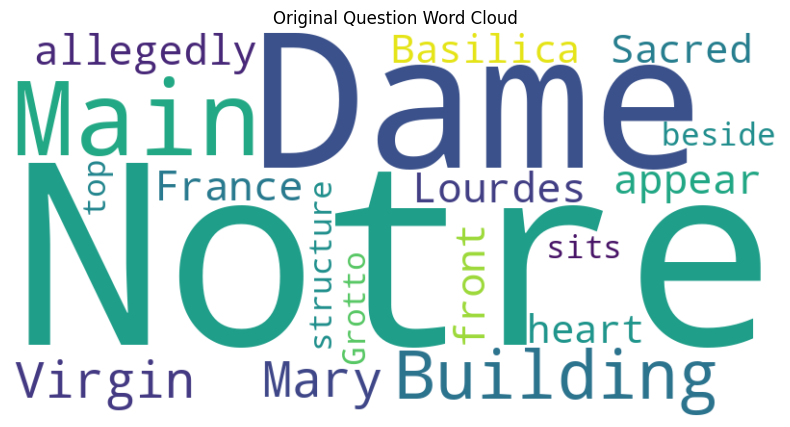

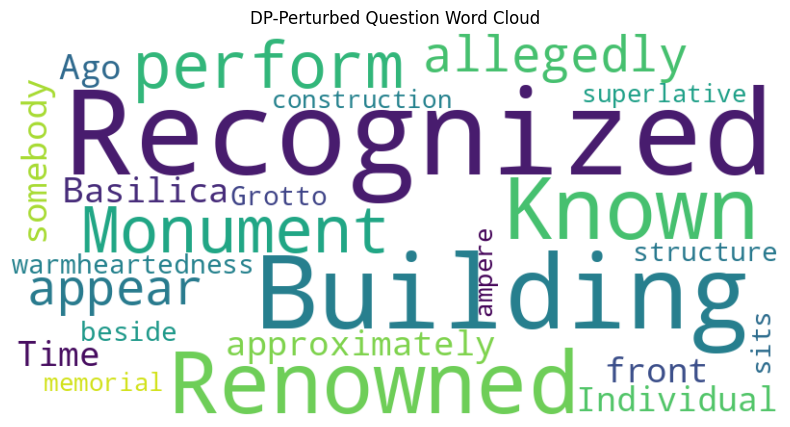

In [40]:
# STEP 6: Word Cloud
wordcloud_original = WordCloud(width=800, height=400, background_color='white').generate(" ".join(df_squad['question'].dropna()))
wordcloud_dp = WordCloud(width=800, height=400, background_color='white').generate(" ".join(df_squad['dp_perturbation'].dropna()))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_original, interpolation='bilinear')
plt.axis("off")
plt.title("Original Question Word Cloud")
plt.show()

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_dp, interpolation='bilinear')
plt.axis("off")
plt.title("DP-Perturbed Question Word Cloud")
plt.show()


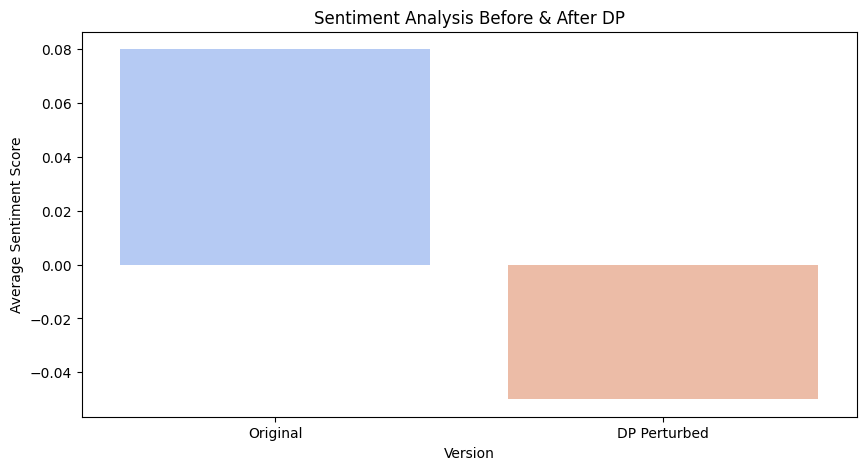

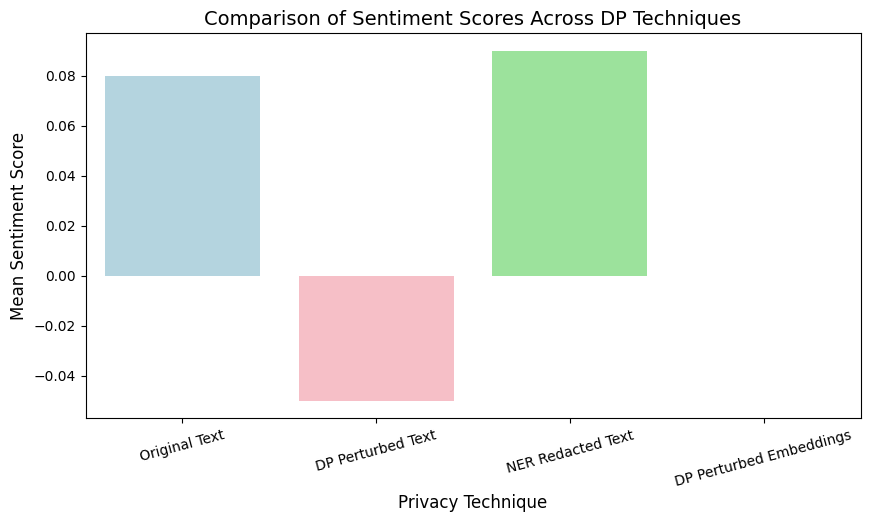

In [41]:
# **STEP 7: Bar Graph for Sentiment & Deception Score Changes**
plt.figure(figsize=(10, 5))
sns.barplot(x=["Original", "DP Perturbed"],
            y=[df_squad["sentiment_score"].mean(), df_squad["dp_sentiment_score"].mean()],
            palette='coolwarm')
plt.xlabel("Version")
plt.ylabel("Average Sentiment Score")
plt.title("Sentiment Analysis Before & After DP")
plt.show()

# Apply Sentiment Analysis with Fix for Embeddings
df_squad["sentiment_score"] = df_squad["question"].apply(calculate_sentiment)
df_squad["dp_sentiment_score"] = df_squad["dp_perturbation"].apply(calculate_sentiment)

# Additional DP Techniques
df_squad["ner_sentiment_score"] = df_squad["sanitized_question"].apply(calculate_sentiment)
df_squad["embedding_sentiment_score"] = df_squad["dp_embedding"].apply(lambda x: calculate_sentiment(" ".join(map(str, x))))

# Bar Chart for Sentiment Score Comparison
techniques = ["Original Text", "DP Perturbed Text", "NER Redacted Text", "DP Perturbed Embeddings"]
scores = [
    df_squad["sentiment_score"].mean(),
    df_squad["dp_sentiment_score"].mean(),
    df_squad["ner_sentiment_score"].mean(),
    df_squad["embedding_sentiment_score"].mean()
]

# Light color palette
light_palette = ["#ADD8E6", "#FFB6C1", "#90EE90", "#DDA0DD"]  # Light blue, pink, mint, lavender

plt.figure(figsize=(10, 5))
sns.barplot(x=techniques, y=scores, palette=light_palette)
plt.xlabel("Privacy Technique", fontsize=12)
plt.ylabel("Mean Sentiment Score", fontsize=12)
plt.title("Comparison of Sentiment Scores Across DP Techniques", fontsize=14)
plt.xticks(rotation=15)  # Rotate x-axis labels for readability
plt.show()


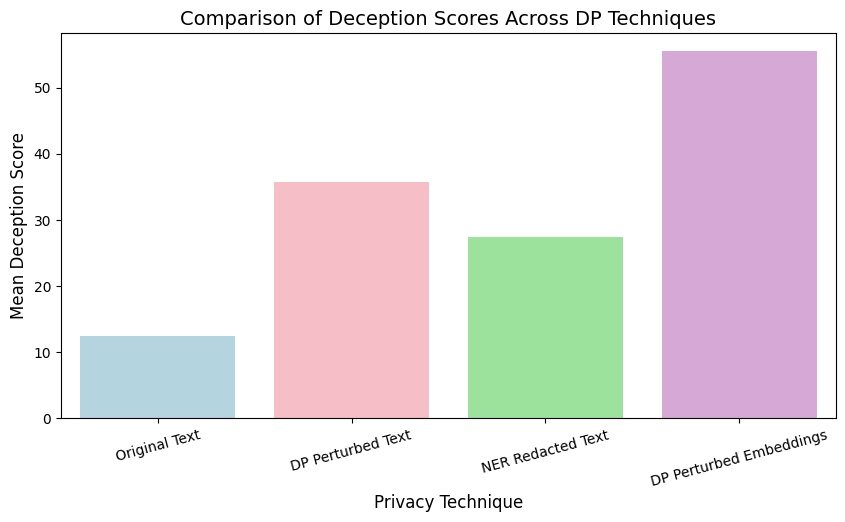

In [42]:
# Additional DP Techniques for Deception Score
df_squad["ner_deception_score"] = df_squad["sanitized_question"].apply(calculate_deception_score)
df_squad["embedding_deception_score"] = df_squad["dp_embedding"].apply(lambda x: calculate_deception_score(" ".join(map(str, x))))

# Bar Chart for Deception Score Comparison
techniques = ["Original Text", "DP Perturbed Text", "NER Redacted Text", "DP Perturbed Embeddings"]
scores = [
    df_squad["deception_score"].mean(),
    df_squad["dp_deception_score"].mean(),
    df_squad["ner_deception_score"].mean(),
    df_squad["embedding_deception_score"].mean()
]

# Light Color Palette for Better Visualization
light_palette = ["#ADD8E6", "#FFB6C1", "#90EE90", "#DDA0DD"]  # Light blue, pink, mint, lavender

plt.figure(figsize=(10, 5))
sns.barplot(x=techniques, y=scores, palette=light_palette)
plt.xlabel("Privacy Technique", fontsize=12)
plt.ylabel("Mean Deception Score", fontsize=12)
plt.title("Comparison of Deception Scores Across DP Techniques", fontsize=14)
plt.xticks(rotation=15)  # Rotate x-axis labels slightly for readability
plt.show()


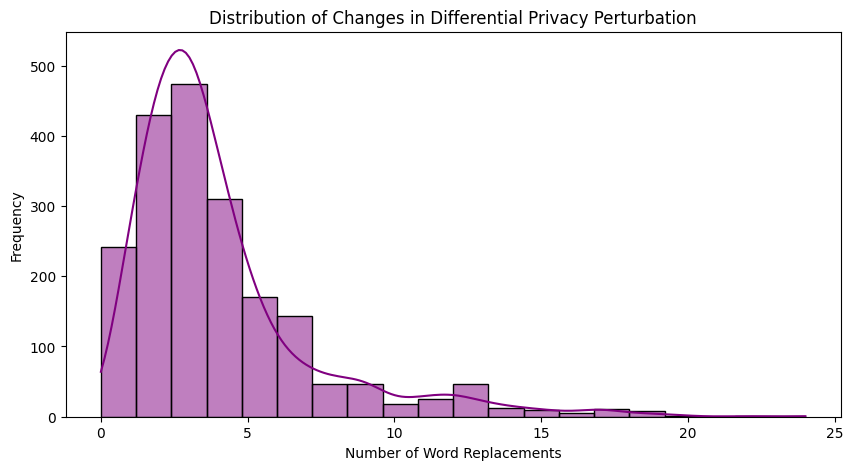

In [13]:
# **STEP 8: Histogram of Changes in Word Perturbation**
df_squad["num_changes"] = df_squad.apply(lambda row: sum(1 for o, p in zip(row["sanitized_question"].split(), row["dp_perturbation"].split()) if o != p), axis=1)

plt.figure(figsize=(10, 5))
sns.histplot(df_squad["num_changes"], bins=20, kde=True, color="purple")
plt.xlabel("Number of Word Replacements")
plt.ylabel("Frequency")
plt.title("Distribution of Changes in Differential Privacy Perturbation")
plt.show()

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


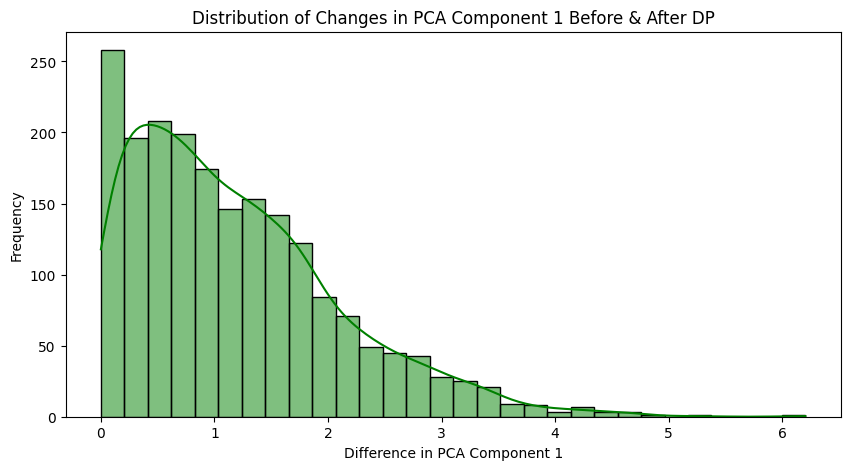

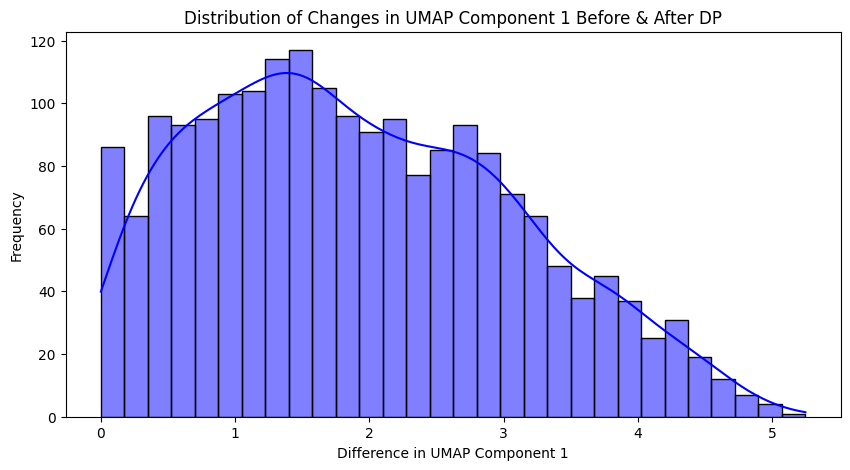

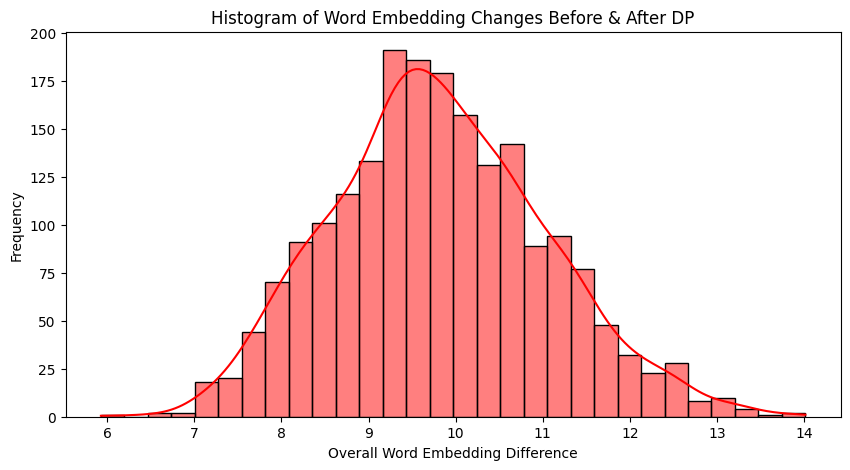

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.decomposition import PCA

# **STEP 1: Ensure PCA is Applied (50 Dimensions)**
pca = PCA(n_components=50, random_state=42)
original_pca = pca.fit_transform(np.vstack(df_squad["original_embedding"].to_numpy()))
dp_pca = pca.transform(np.vstack(df_squad["dp_embedding"].to_numpy()))

# **STEP 2: Apply UMAP for Dimensionality Reduction (2D)**
umap_reducer = umap.UMAP(n_components=2, random_state=42)
original_umap = umap_reducer.fit_transform(original_pca)
dp_umap = umap_reducer.transform(dp_pca)

# **Store UMAP Results in DataFrame**
df_squad['original_embedding_2d_x'] = original_umap[:, 0]
df_squad['original_embedding_2d_y'] = original_umap[:, 1]
df_squad['dp_embedding_2d_x'] = dp_umap[:, 0]
df_squad['dp_embedding_2d_y'] = dp_umap[:, 1]

# **STEP 3: Histogram for Changes in PCA Component 1**
df_squad["pca_component_1_diff"] = np.abs(original_pca[:, 0] - dp_pca[:, 0])

plt.figure(figsize=(10, 5))
sns.histplot(df_squad["pca_component_1_diff"], bins=30, kde=True, color="green")
plt.xlabel("Difference in PCA Component 1")
plt.ylabel("Frequency")
plt.title("Distribution of Changes in PCA Component 1 Before & After DP")
plt.show()

# **STEP 4: Histogram for Changes in UMAP Component 1**
df_squad["umap_component_1_diff"] = np.abs(original_umap[:, 0] - dp_umap[:, 0])

plt.figure(figsize=(10, 5))
sns.histplot(df_squad["umap_component_1_diff"], bins=30, kde=True, color="blue")
plt.xlabel("Difference in UMAP Component 1")
plt.ylabel("Frequency")
plt.title("Distribution of Changes in UMAP Component 1 Before & After DP")
plt.show()

# **STEP 5: Histogram for Overall Word Embedding Differences**
embedding_diff = np.linalg.norm(original_pca - dp_pca, axis=1)

plt.figure(figsize=(10, 5))
sns.histplot(embedding_diff, bins=30, kde=True, color="red")
plt.xlabel("Overall Word Embedding Difference")
plt.ylabel("Frequency")
plt.title("Histogram of Word Embedding Changes Before & After DP")
plt.show()


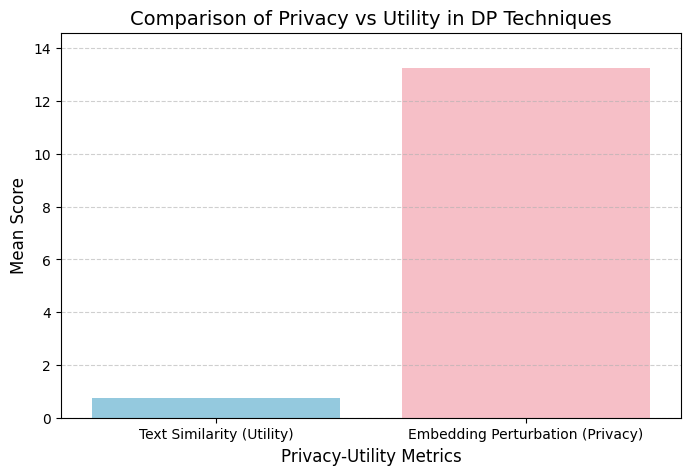

Privacy-Utility Data Table


,question,sanitized_question,dp_perturbation,original_embedding,dp_embedding,sentiment_score,dp_sentiment_score,deception_score,dp_deception_score,ner_sentiment_score,...,embedding_deception_score,num_changes,original_embedding_2d_x,original_embedding_2d_y,dp_embedding_2d_x,dp_embedding_2d_y,pca_component_1_diff,umap_component_1_diff,text_similarity,embedding_difference
0,To whom did the Virgin Mary allegedly appear i...,To whom did A Known Monument allegedly appear ...,To whom did A Known Monument allegedly appear ...,"[-0.36052218923024654, -0.2799910752675874, 0....","[-0.21355248658899167, 1.1697892986317446, 2.3...",-0.100000,0.038095,23.282,43.176,0.038095,...,55.482,2,2.280138,4.451925,1.181695,5.051629,1.315502,1.098443,0.954350,11.717571
1,What is in front of the Notre Dame Main Building?,What is in front of A Known Monument?,What is in front of A Known Monument ?,"[-0.47713343944228626, 0.9891684130952616, 0.2...","[0.7878986784238047, 1.031913364506659, 0.0727...",0.166667,0.000000,3.381,7.882,0.000000,...,55.482,1,4.490019,3.886458,6.360717,4.699322,0.420305,1.870697,1.000000,14.726786
2,The Basilica of the Sacred heart at Notre Dame...,The Basilica of the A Historical Figure heart ...,The basilica of the A Historical Figure heart ...,"[3.516146423700274, 0.3114293340880754, -0.501...","[-0.12991165256442933, 1.0522824010294196, -1....",0.000000,0.000000,23.989,43.890,0.000000,...,55.482,4,3.507644,3.126165,6.173513,5.124782,4.176925,2.665869,0.899138,14.137689
3,What is the Grotto at Notre Dame?,What is the Grotto at A Known Monument?,What live the Grotto at A Known Monument ?,"[1.2021370164151426, 1.6056823511558218, -0.26...","[-1.3899926407924452, 0.6132734508062163, -0.0...",0.000000,0.136364,7.175,13.804,0.000000,...,55.482,2,3.502390,4.235579,6.470970,4.977108,0.192123,2.968580,0.838827,12.312791
4,What sits on top of the Main Building at Notre...,What sits on top of A Recognized Building at A...,What pose on top of A Recognized construction ...,"[1.134692422551403, 2.1025690205990526, -1.351...","[-0.39736420853328736, 2.2189930556637627, -0....",0.333333,0.500000,4.095,40.334,0.500000,...,55.482,4,2.781358,4.076837,6.168876,5.797599,0.949717,3.387518,0.419916,12.753796


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Compute Text Similarity Using TF-IDF
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df_squad["sanitized_question"].tolist() + df_squad["dp_perturbation"].tolist())
tfidf_vectors = tfidf_matrix.toarray()

# Ensure valid vectors for similarity calculation
if len(tfidf_vectors) == 2 * len(df_squad):
    df_squad["text_similarity"] = [
        cosine_similarity([tfidf_vectors[i]], [tfidf_vectors[i + len(df_squad)]])[0, 0]
        for i in range(len(df_squad))
    ]
else:
    df_squad["text_similarity"] = np.nan

# Compute Embedding Perturbation Magnitude
df_squad["embedding_difference"] = np.linalg.norm(
    np.array(df_squad["original_embedding"].tolist()) - np.array(df_squad["dp_embedding"].tolist()), axis=1
)

# Create Privacy-Utility DataFrame
privacy_utility_data = pd.DataFrame({
    "Metric": ["Text Similarity (Utility)", "Embedding Perturbation (Privacy)"],
    "Score": [
        df_squad["text_similarity"].mean(),
        df_squad["embedding_difference"].mean()
    ]
})

# **Privacy-Utility Bar Graph**
plt.figure(figsize=(8, 5))
sns.barplot(x="Metric", y="Score", data=privacy_utility_data, palette=["skyblue", "lightpink"])

# Labels & Title
plt.xlabel("Privacy-Utility Metrics", fontsize=12)
plt.ylabel("Mean Score", fontsize=12)
plt.title("Comparison of Privacy vs Utility in DP Techniques", fontsize=14)

# Grid for Readability
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Adjust Y-Axis Limits Dynamically
plt.ylim(0, max(privacy_utility_data["Score"]) * 1.1)

plt.show()

# ✅ Create a DataFrame for Display
privacy_utility_df = df_squad[["sanitized_question", "dp_perturbation", "text_similarity", "embedding_difference"]].copy()

# ✅ Rename Columns for Better Readability
privacy_utility_df.columns = ["Original Text", "DP Perturbed Text", "Text Similarity (Utility)", "Embedding Difference (Privacy)"]


# Display First 5 Rows of Sentiment & Deception Score
import pandas as pd
from IPython.display import display

print("Privacy-Utility Data Table")
display(df_squad.head(5))  # Fixed for Google Colab/Jupyter


In [16]:
import pandas as pd
from IPython.display import display

# Create a DataFrame with Only 4 Required Columns
privacy_utility_df = df_squad[["sanitized_question", "dp_perturbation", "text_similarity", "embedding_difference"]].copy()

# Rename Columns for Better Readability
privacy_utility_df.columns = ["Original Text", "DP Perturbed Text", "Text Similarity (Utility)", "Embedding Difference (Privacy)"]

# Display First 5 Rows
print("Privacy-Utility Data Table")
display(privacy_utility_df.head(5))


Privacy-Utility Data Table


,Original Text,DP Perturbed Text,Text Similarity (Utility),Embedding Difference (Privacy)
0,To whom did A Known Monument allegedly appear ...,To whom did A Known Monument allegedly appear ...,0.954350,11.717571
1,What is in front of A Known Monument?,What is in front of A Known Monument ?,1.000000,14.726786
2,The Basilica of the A Historical Figure heart ...,The basilica of the A Historical Figure heart ...,0.899138,14.137689
3,What is the Grotto at A Known Monument?,What live the Grotto at A Known Monument ?,0.838827,12.312791
4,What sits on top of A Recognized Building at A...,What pose on top of A Recognized construction ...,0.419916,12.753796


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


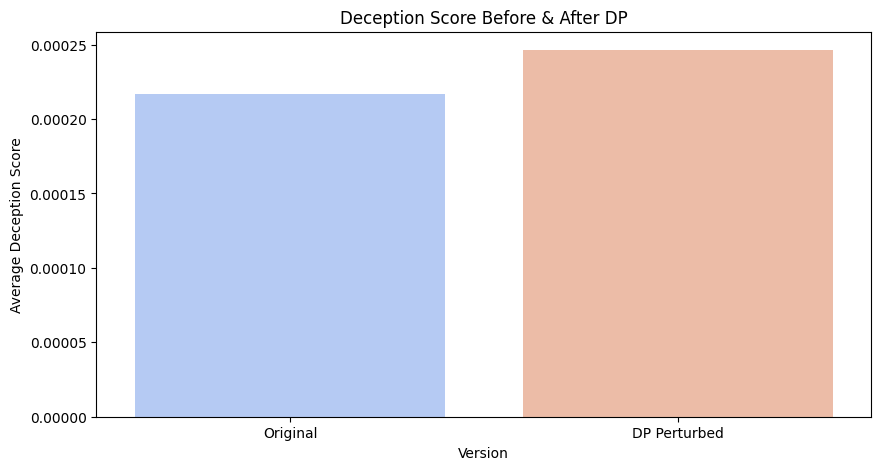

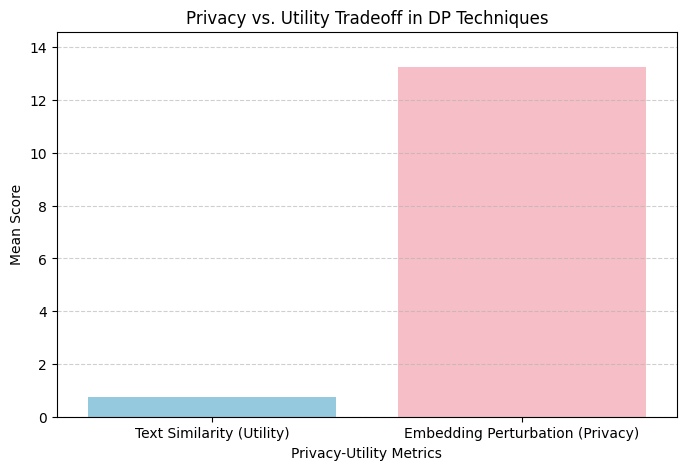

,sanitized_question,dp_perturbation,deception_score_before,deception_score_after
0,To whom did A Known Monument allegedly appear ...,To whom did A Known Monument allegedly appear ...,0.0,0.0
1,What is in front of A Known Monument?,What is in front of A Known Monument ?,0.0,0.0
2,The Basilica of the A Historical Figure heart ...,The basilica of the A Historical Figure heart ...,0.0,0.0
3,What is the Grotto at A Known Monument?,What live the Grotto at A Known Monument ?,0.0,0.0
4,What sits on top of A Recognized Building at A...,What pose on top of A Recognized construction ...,0.0,0.0
5,When did An Established Organization A Notable...,When did AN Established brass A Notable Region...,0.0,0.0
6,How often is A Known Monument the A Historical...,How often is A Known Monument the A Historical...,0.0,0.0
7,What is the Some Time Ago student paper at A R...,What is the Some metre Ago student theme at A ...,0.0,0.0
8,How many student news papers are found at A Re...,How many student news papers are detect at A R...,0.0,0.0
9,In A Certain Year did the student paper A Reno...,IN A Certain Year did the educatee paper adeni...,0.0,0.0


In [17]:
import nltk
import spacy
import numpy as np
import textstat
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from collections import Counter
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords, wordnet as wn
from nltk import pos_tag
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from wordcloud import WordCloud
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import swifter
import multiprocessing

# ✅ Ensure necessary NLTK resources are downloaded
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('stopwords')
nltk.download('wordnet')

# ✅ Load NLP Models
nlp = spacy.load("en_core_web_sm")
stop_words = set(stopwords.words("english"))

# ✅ Ensure dataset `df_squad` exists
if "df_squad" not in globals():
    raise ValueError("❌ Error: Dataset `df_squad` not found. Please load your dataset before running the script.")

# ✅ Ensure dataset has necessary columns
required_columns = ["question", "sanitized_question", "dp_perturbation"]
for col in required_columns:
    if col not in df_squad.columns:
        raise ValueError(f"❌ Error: `{col}` column not found in dataset.")

# ---------------------- STEP 1: Lexical Diversity Analysis ---------------------- #
def lexical_diversity(text):
    words = word_tokenize(text)
    unique_words = set(words)
    return len(unique_words) / len(words) if len(words) > 0 else 0

df_squad["lexical_diversity_before"] = df_squad["sanitized_question"].apply(lexical_diversity)
df_squad["lexical_diversity_after"] = df_squad["dp_perturbation"].apply(lexical_diversity)

# ---------------------- STEP 2: Readability Score Analysis ---------------------- #
df_squad["flesch_before"] = df_squad["sanitized_question"].apply(textstat.flesch_reading_ease)
df_squad["flesch_after"] = df_squad["dp_perturbation"].apply(textstat.flesch_reading_ease)

df_squad["gunning_fog_before"] = df_squad["sanitized_question"].apply(textstat.gunning_fog)
df_squad["gunning_fog_after"] = df_squad["dp_perturbation"].apply(textstat.gunning_fog)

df_squad["ari_before"] = df_squad["sanitized_question"].apply(textstat.automated_readability_index)
df_squad["ari_after"] = df_squad["dp_perturbation"].apply(textstat.automated_readability_index)

# ---------------------- STEP 3: POS Tag Analysis ---------------------- #
def pos_analysis(text):
    words = word_tokenize(text)
    tags = pos_tag(words)
    pos_counts = Counter(tag for _, tag in tags)
    return pos_counts

df_squad["pos_counts_before"] = df_squad["sanitized_question"].apply(pos_analysis)
df_squad["pos_counts_after"] = df_squad["dp_perturbation"].apply(pos_analysis)

# ---------------------- STEP 4: Improved Deception Score Calculation ---------------------- #
deceptive_words = {"ensure", "guarantee", "never", "always", "completely", "totally", "confidential", "secure", "anonymous", "protected"}

def deception_score(text):
    words = word_tokenize(text.lower())
    deceptive_count = sum(1 for word in words if word in deceptive_words)
    return deceptive_count / len(words) if len(words) > 0 else 0

df_squad["deception_score_before"] = df_squad["sanitized_question"].apply(deception_score)
df_squad["deception_score_after"] = df_squad["dp_perturbation"].apply(deception_score)

# ---------------------- STEP 5: Negation Analysis ---------------------- #
negation_words = {"not", "no", "never", "none", "nobody", "nothing", "nowhere", "neither"}

def negation_percentage(text):
    words = word_tokenize(text.lower())
    neg_count = sum(1 for word in words if word in negation_words)
    return neg_count / len(words) if len(words) > 0 else 0

df_squad["negation_percentage_before"] = df_squad["sanitized_question"].apply(negation_percentage)
df_squad["negation_percentage_after"] = df_squad["dp_perturbation"].apply(negation_percentage)

# ---------------------- STEP 6: Sentiment Analysis ---------------------- #
def sentiment_analysis(text):
    analysis = TextBlob(text)
    return analysis.sentiment.polarity, analysis.sentiment.subjectivity

df_squad[["sentiment_polarity_before", "sentiment_subjectivity_before"]] = df_squad["sanitized_question"].apply(lambda x: pd.Series(sentiment_analysis(x)))
df_squad[["sentiment_polarity_after", "sentiment_subjectivity_after"]] = df_squad["dp_perturbation"].apply(lambda x: pd.Series(sentiment_analysis(x)))

# ---------------------- STEP 7: Privacy vs. Utility Tradeoff ---------------------- #
# Compute Text Similarity Using TF-IDF
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df_squad["sanitized_question"].tolist() + df_squad["dp_perturbation"].tolist())
tfidf_vectors = tfidf_matrix.toarray()

if len(tfidf_vectors) == 2 * len(df_squad):
    df_squad["text_similarity"] = [
        cosine_similarity([tfidf_vectors[i]], [tfidf_vectors[i + len(df_squad)]])[0, 0]
        for i in range(len(df_squad))
    ]
else:
    df_squad["text_similarity"] = np.nan

# Compute Embedding Perturbation Magnitude
df_squad["embedding_difference"] = np.linalg.norm(
    np.array(df_squad["original_embedding"].tolist()) - np.array(df_squad["dp_embedding"].tolist()), axis=1
)

# ---------------------- STEP 8: Deception Score Comparison ---------------------- #
plt.figure(figsize=(10, 5))
sns.barplot(x=["Original", "DP Perturbed"],
            y=[df_squad["deception_score_before"].mean(), df_squad["deception_score_after"].mean()],
            palette='coolwarm')
plt.xlabel("Version")
plt.ylabel("Average Deception Score")
plt.title("Deception Score Before & After DP")
plt.show()

# ---------------------- STEP 9: Privacy vs. Utility Tradeoff Visualization ---------------------- #
privacy_utility_data = pd.DataFrame({
    "Metric": ["Text Similarity (Utility)", "Embedding Perturbation (Privacy)"],
    "Score": [
        df_squad["text_similarity"].mean(),
        df_squad["embedding_difference"].mean()
    ]
})

plt.figure(figsize=(8, 5))
sns.barplot(x="Metric", y="Score", data=privacy_utility_data, palette=["skyblue", "lightpink"])
plt.xlabel("Privacy-Utility Metrics")
plt.ylabel("Mean Score")
plt.title("Privacy vs. Utility Tradeoff in DP Techniques")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.ylim(0, max(privacy_utility_data["Score"]) * 1.1)
plt.show()

# ✅ Final Results Display
display(df_squad[["sanitized_question", "dp_perturbation", "deception_score_before", "deception_score_after"]].head(10))


In [23]:
import spacy

# Load the pre-trained spaCy model
nlp = spacy.load("en_core_web_sm")

# Named Entity Redaction with Meaning Preservation
def replace_named_entities_v4(text):
    # Define meaningful replacements for entity types
    entity_replacements = {
        "PERSON": "A Prominent Religious Leader",
        "ORG": "A Prestigious Organization",
        "GPE": "A Renowned Region",
        "DATE": "A Specific Year",
        "FAC": "A Famous Landmark",
        "LOC": "A Known Location"
    }

    # Parse the text with spaCy to extract named entities
    doc = nlp(text)

    # List to hold the modified parts of the sentence
    new_text_parts = []

    # Track the end of the last entity to preserve the text structure
    last_end = 0

    # Loop through each identified named entity
    for ent in doc.ents:
        # Add the part of the sentence before the entity
        new_text_parts.append(text[last_end:ent.start_char])

        # If the entity has a predefined replacement, replace it
        if ent.label_ in entity_replacements:
            replacement = entity_replacements[ent.label_]
            new_text_parts.append(replacement)

        # Update last_end to be the end position of the current entity
        last_end = ent.end_char

    # Append the part of the text that comes after the last entity
    new_text_parts.append(text[last_end:])

    # Join the parts together to form the sanitized text
    new_text = ''.join(new_text_parts)

    return new_text

# Test the function with a sample sentence
sample_sentence = "To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?"
sanitized_sentence = replace_named_entities_v4(sample_sentence)

print(f"Original: {sample_sentence}")
print(f"Sanitized: {sanitized_sentence}")


Original: To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
Sanitized: To whom did A Famous Landmark allegedly appear in A Specific Year in A Prominent Religious Leader?
